In [32]:

import fitz  # PyMuPDF
import numpy as np
import cv2
from PIL import Image


In [33]:
pdf_path = r'C:\Users\matheus.carneiro\Projetos\well-report-extractor\inputs\22062026_modelo_perfil_v1.pdf'

In [34]:

doc = fitz.open(pdf_path)
page = doc.load_page(0)

pix = page.get_pixmap()  # render page
img_pil = Image.frombytes(
    "RGB",
    [pix.width, pix.height],
    pix.samples
)
doc.close()


In [35]:

img = np.array(img_pil)
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

In [36]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(
    gray, 150, 255, cv2.THRESH_BINARY_INV
)

kernel = np.ones((3, 3), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

thresh


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(792, 612), dtype=uint8)

In [37]:
contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

contours

(array([[[514, 652]],
 
        [[513, 653]],
 
        [[513, 657]],
 
        [[514, 658]],
 
        [[515, 658]],
 
        [[516, 657]],
 
        [[516, 653]],
 
        [[515, 652]]], dtype=int32),
 array([[[508, 652]],
 
        [[509, 653]],
 
        [[509, 657]],
 
        [[508, 658]],
 
        [[510, 658]],
 
        [[509, 657]],
 
        [[509, 652]]], dtype=int32),
 array([[[495, 652]],
 
        [[495, 653]],
 
        [[496, 652]],
 
        [[498, 652]],
 
        [[499, 653]],
 
        [[499, 655]],
 
        [[497, 657]],
 
        [[495, 657]],
 
        [[494, 656]],
 
        [[494, 655]],
 
        [[494, 657]],
 
        [[493, 658]],
 
        [[494, 657]],
 
        [[496, 657]],
 
        [[497, 658]],
 
        [[499, 658]],
 
        [[500, 657]],
 
        [[502, 657]],
 
        [[503, 658]],
 
        [[504, 658]],
 
        [[505, 657]],
 
        [[505, 653]],
 
        [[504, 652]],
 
        [[503, 652]],
 
        [[502, 653]],
 
        [[500,

In [38]:

max_area = 0
best_box = None

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    area = w * h

    if area > max_area:
        max_area = area
        best_box = (x, y, w, h)
        
best_box


(44, 166, 316, 474)

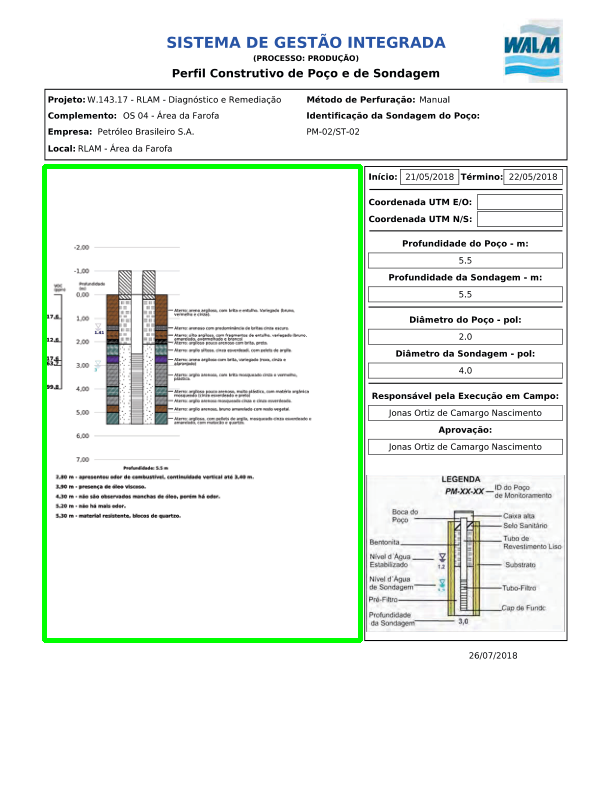

In [39]:

debug_img = img.copy()
x, y, w, h = best_box
cv2.rectangle(debug_img, (x, y), (x + w, y + h), (0, 255, 0), 3)

display(Image.fromarray(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB)))
